In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd # 

In [2]:
df = pd.read_csv('match_data_50_tourns_modified.csv')
df.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p1_frames_won_3_years,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id
0,Cao Yupeng,Jiang Jun,9,1411,1044,0.918016,0.714532,341,179,2302,...,242,32,17,32,17,5,0,0.0,1.000000,5808
1,Siripaporn Nuanthakhamjan,Zhou Yuelong,9,965,1384,0.056881,0.259705,3,0,23,...,4,245,118,808,430,2,5,1.0,0.285714,5808
2,Wu Yize,Allan Taylor,9,1342,1237,0.656987,0.565251,78,37,552,...,215,101,49,336,147,5,3,0.0,0.625000,5808
3,Ben Woollaston,Oliver Brown,9,1412,1146,0.845318,0.660383,803,454,5053,...,282,91,35,235,97,5,2,0.0,0.714286,5808
4,Andres Petrov,Mark Williams,9,1045,1611,0.017765,0.195447,51,18,304,...,61,281,170,1112,649,2,5,1.0,0.285714,5808


In [3]:
n = round(len(df) / 6)
df_holdout = df.tail(n)
df=df.iloc[:-n]

### XG Boost with statistical features


In [4]:
features_to_remove = ['player1', 'player2', 'player1_elo','player2_elo','elo_match_win_rate','elo_frame_win_rate',
                      'score1','score2','match_result','win_percentage','tournament_id']
X = df.drop(columns=features_to_remove) 
y = df['win_percentage']

In [5]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, root_mean_squared_error
import numpy as np

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [7]:
train_sizes = []
for train_index, _ in tscv.split(X):
    train_sizes.append(len(train_index))
train_sizes = np.array(train_sizes)
cv_results = grid_search.cv_results_
n_splits = tscv.get_n_splits()
n_params = len(cv_results['params'])

weighted_avg_rmse = []

for i in range(n_params):
    fold_scores = np.array([cv_results[f'split{j}_test_score'][i] for j in range(n_splits)])
    # weighted average by train sizes
    weighted_score = np.average(fold_scores, weights=train_sizes)
    weighted_avg_rmse.append(weighted_score)
best_index = np.argmax(weighted_avg_rmse)  # scores are negative RMSE, so max is best
best_params = cv_results['params'][best_index]
best_rmse = -weighted_avg_rmse[best_index]  # convert to positive RMSE

print("Best params (weighted):", best_params)
print("Best weighted average RMSE:", best_rmse)

Best params (weighted): {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best weighted average RMSE: 0.27619259383448563


### XG Boost with statistical features based on player statistic differences

In [8]:
dfm = df
dfm['p1_matches_win_ratio']=dfm['p1_matches_won']/df['p1_matches_played']
dfm['p2_matches_win_ratio']=dfm['p2_matches_won']/df['p2_matches_played']
dfm['p1_frames_win_ratio']=dfm['p1_frames_won']/df['p1_frames_played']
dfm['p2_frames_win_ratio']=dfm['p2_frames_won']/df['p2_frames_played']
dfm['p1_frames_win_ratio_1_year']=dfm['p1_frames_won_1_year']/df['p1_frames_played_1_year']
dfm['p2_frames_win_ratio_1_year']=dfm['p2_frames_won_1_year']/df['p2_frames_played_1_year']
dfm['p1_frames_win_ratio_3_years']=dfm['p1_frames_won_3_years']/df['p1_frames_played_3_years']
dfm['p2_frames_win_ratio_3_years']=dfm['p2_frames_won_3_years']/df['p2_frames_played_3_years']
dfm.fillna(0.5, inplace=True)
dfm['matches_win_ratio_diff']=dfm['p1_matches_win_ratio']-dfm['p2_matches_win_ratio']
dfm['frames_win_ratio_diff']=dfm['p1_frames_win_ratio']-dfm['p2_frames_win_ratio']
dfm['frames_win_ratio_diff_1_year']=dfm['p1_frames_win_ratio_1_year']-dfm['p2_frames_win_ratio_1_year']
dfm['frames_win_ratio_diff_3_years']=dfm['p1_frames_win_ratio_3_years']-dfm['p2_frames_win_ratio_3_years']

In [9]:
selected_features = ['matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years']
X = dfm[selected_features]
y = dfm['win_percentage']

In [10]:
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [11]:
train_sizes = []
for train_index, _ in tscv.split(X):
    train_sizes.append(len(train_index))
train_sizes = np.array(train_sizes)
cv_results = grid_search.cv_results_
n_splits = tscv.get_n_splits()
n_params = len(cv_results['params'])

weighted_avg_rmse = []

for i in range(n_params):
    fold_scores = np.array([cv_results[f'split{j}_test_score'][i] for j in range(n_splits)])
    # weighted average by train sizes
    weighted_score = np.average(fold_scores, weights=train_sizes)
    weighted_avg_rmse.append(weighted_score)
best_index = np.argmax(weighted_avg_rmse)  # scores are negative RMSE, so max is best
best_params = cv_results['params'][best_index]
best_rmse = -weighted_avg_rmse[best_index]  # convert to positive RMSE

print("Best params (weighted):", best_params)
print("Best weighted average RMSE:", best_rmse)

Best params (weighted): {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best weighted average RMSE: 0.28017728683286003


In [12]:
final_model = XGBRegressor(**best_params, objective='reg:squarederror', random_state=20)
final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=20, ...)

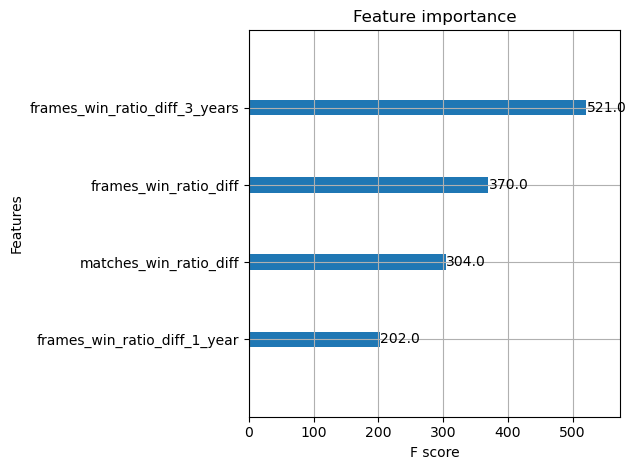

In [13]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(final_model, importance_type='weight')  
plt.tight_layout()
plt.show()

### XG Boost with player elo ratings and features based on player statistic differences

In [14]:
selected_features = ['player1_elo','player2_elo','matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years']
X = dfm[selected_features]
y = dfm['win_percentage']

In [15]:
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [16]:
train_sizes = []
for train_index, _ in tscv.split(X):
    train_sizes.append(len(train_index))
train_sizes = np.array(train_sizes)
cv_results = grid_search.cv_results_
n_splits = tscv.get_n_splits()
n_params = len(cv_results['params'])

weighted_avg_rmse = []

for i in range(n_params):
    fold_scores = np.array([cv_results[f'split{j}_test_score'][i] for j in range(n_splits)])
    # weighted average by train sizes
    weighted_score = np.average(fold_scores, weights=train_sizes)
    weighted_avg_rmse.append(weighted_score)
best_index = np.argmax(weighted_avg_rmse)  # scores are negative RMSE, so max is best
best_params = cv_results['params'][best_index]
best_rmse = -weighted_avg_rmse[best_index]  # convert to positive RMSE

print("Best params (weighted):", best_params)
print("Best weighted average RMSE:", best_rmse)

Best params (weighted): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best weighted average RMSE: 0.27415304695656845


### XG Boost on all available features

In [17]:
features_to_remove = ['player1', 'player2', 
                      'score1','score2','match_result','win_percentage','tournament_id']
X = df.drop(columns=features_to_remove) 
y = df['win_percentage']

In [20]:
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(objective='reg:squarederror', random_state=20, verbosity=0)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring=rmse_scorer,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END c

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=20, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=2)

In [21]:
train_sizes = []
for train_index, _ in tscv.split(X):
    train_sizes.append(len(train_index))
train_sizes = np.array(train_sizes)
cv_results = grid_search.cv_results_
n_splits = tscv.get_n_splits()
n_params = len(cv_results['params'])

weighted_avg_rmse = []

for i in range(n_params):
    fold_scores = np.array([cv_results[f'split{j}_test_score'][i] for j in range(n_splits)])
    # weighted average by train sizes
    weighted_score = np.average(fold_scores, weights=train_sizes)
    weighted_avg_rmse.append(weighted_score)
best_index = np.argmax(weighted_avg_rmse)  # scores are negative RMSE, so max is best
best_params = cv_results['params'][best_index]
best_rmse = -weighted_avg_rmse[best_index]  # convert to positive RMSE

print("Best params (weighted):", best_params)
print("Best weighted average RMSE:", best_rmse)

Best params (weighted): {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best weighted average RMSE: 0.27146468644786564
